In [11]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
%matplotlib inline

In [6]:
import numpy as np
data=np.loadtxt('ex1data1.txt',delimiter=',')
x_train = data[:,0]
y_train=data[:,1]

print ("x_train",x_train)
print ("y_train",y_train)

x_train [ 6.1101  5.5277  8.5186  7.0032  5.8598  8.3829  7.4764  8.5781  6.4862
  5.0546  5.7107 14.164   5.734   8.4084  5.6407  5.3794  6.3654  5.1301
  6.4296  7.0708  6.1891 20.27    5.4901  6.3261  5.5649 18.945  12.828
 10.957  13.176  22.203   5.2524  6.5894  9.2482  5.8918  8.2111  7.9334
  8.0959  5.6063 12.836   6.3534  5.4069  6.8825 11.708   5.7737  7.8247
  7.0931  5.0702  5.8014 11.7     5.5416  7.5402  5.3077  7.4239  7.6031
  6.3328  6.3589  6.2742  5.6397  9.3102  9.4536  8.8254  5.1793 21.279
 14.908  18.959   7.2182  8.2951 10.236   5.4994 20.341  10.136   7.3345
  6.0062  7.2259  5.0269  6.5479  7.5386  5.0365 10.274   5.1077  5.7292
  5.1884  6.3557  9.7687  6.5159  8.5172  9.1802  6.002   5.5204  5.0594
  5.7077  7.6366  5.8707  5.3054  8.2934 13.394   5.4369]
y_train [17.592    9.1302  13.662   11.854    6.8233  11.886    4.3483  12.
  6.5987   3.8166   3.2522  15.505    3.1551   7.2258   0.71618  3.5129
  5.3048   0.56077  3.6518   5.3893   3.1386  21.767    4.

In [18]:
print ('type of x train ',type(x_train ))
print ("first five element of x_train are :\n",x_train[0:5])

type of x train  <class 'numpy.ndarray'>
first five element of x_train are :
 [6.1101 5.5277 8.5186 7.0032 5.8598]


In [17]:
print ('type of y train ',type(y_train ))
print ("first five element of y_train are :\n",y_train[0:5])

type of y train  <class 'numpy.ndarray'>
first five element of y_train are :
 [17.592   9.1302 13.662  11.854   6.8233]


In [9]:
print ("the shape of x_train is :",x_train.shape )
print ("the shape of y_train is :",y_train.shape )
print ('number of training examples (m)' , len(x_train))

the shape of x_train is : (97,)
the shape of y_train is : (97,)
number of training examples (m) 97


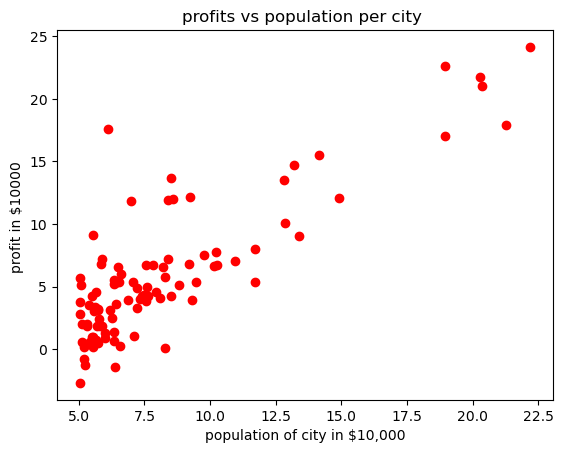

In [ ]:
plt.scatter (x_train,y_train,marker="o",c="r")
plt.title("profits vs population per city ")
plt.ylabel ('profit in $10000 ')
plt.xlabel ('population of city in 10,000')
plt.show()


In [26]:
def compute_cost(x,y,w,b):
    
    m=x.shape[0]
    total_cost=0
    cost=0
    for i in range (m):
        f_wb=w*x[i]+b
        cost+=(f_wb - y[i])**2
    
    total_cost = cost/(2*m)
    print (total_cost)
    return total_cost

    


In [29]:
def compute_gradient(x,y,w,b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range (m):
        f_wb=w*x[i]+b
        dj_db+=f_wb-y[i]
        dj_dw += (f_wb - y[i])*x[i]
    dj_dw /= m
    dj_db /= m
    
    return dj_dw, dj_db

initial_w = 0
initial_b = 0

tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, initial_w, initial_b)
print('Gradient at initial w, b (zeros):', tmp_dj_dw, tmp_dj_db)

test_w = 0.2
test_b = 0.2
tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, test_w, test_b)

print('Gradient at test w, b:', tmp_dj_dw, tmp_dj_db)

Gradient at initial w, b (zeros): -65.32884974555672 -5.83913505154639
Gradient at test w, b: -47.41610118114435 -4.007175051546391


In [38]:
def gradient_descent(x, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):


    m = len(x)

    J_history = []
    w_history = []
    w = copy.deepcopy(w_in) 
    b = b_in

    for i in range(num_iters):

        
        dj_dw, dj_db = gradient_function(x, y, w, b )

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        
        if i<100000:      
            cost =  cost_function(x, y, w, b)
            J_history.append(cost)

        
        if i% math.ceil(num_iters/10) == 0:
            w_history.append(w)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")

    return w, b, J_history, w_history 
    

In [37]:
initial_w = 0.
initial_b = 0.

iterations = 1500
alpha = 0.01

w,b,J_history,w_history = gradient_descent(x_train ,y_train, initial_w, initial_b,compute_cost, compute_gradient, alpha, iterations)
print("w,b found by gradient descent:", w, b)

6.737190464870008
Iteration    0: Cost     6.74   
5.931593568604957
5.901154707081387
5.89522858644422
5.890094943117333
5.885004158443646
5.879932480491416
5.874879094762575
5.8698439118063845
5.8648268653129305
5.8598278899321805
5.85484692057229
5.849883892376585
5.844938740722036
5.840011401218365
5.835101809707228
5.830209902261389
5.825335615183866
5.820478885007098
5.8156396484921515
5.81081784262787
5.806013404630042
5.801226271940627
5.796456382226899
5.791703673380652
5.786968083517397
5.782249550975539
5.777548014315598
5.772863412319381
5.768195683989212
5.76354476854712
5.758910605434049
5.754293134309077
5.7496922950486296
5.745108027745686
5.740540272709014
5.735988970462384
5.7314540617437935
5.7269354875047025
5.722433188909259
5.717947107333528
5.713477184364749
5.709023361800547
5.704585581648199
5.700163786123851
5.695757917651815
5.69136791886375
5.6869937325979825
5.6826353018987055
5.6782925700152935
5.673965480401505
5.669653976714796
5.665358002815552
5.661077

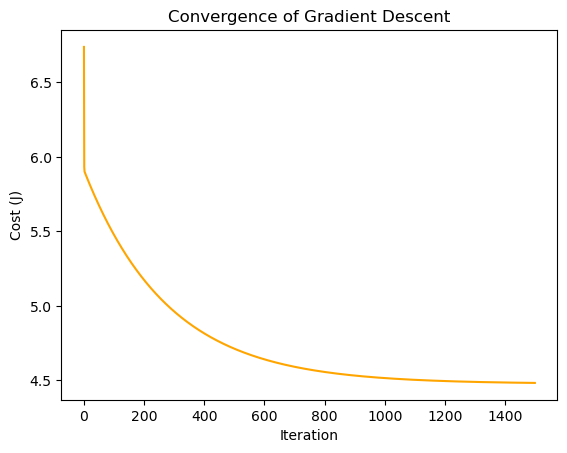

In [40]:
plt.plot(J_history, color="orange")
plt.xlabel("Iteration")
plt.ylabel("Cost (J)")
plt.title("Convergence of Gradient Descent")
plt.show()

In [41]:
m = x_train.shape[0]
predicted = np.zeros(m)

for i in range(m):
    predicted[i] = w * x_train[i] + b

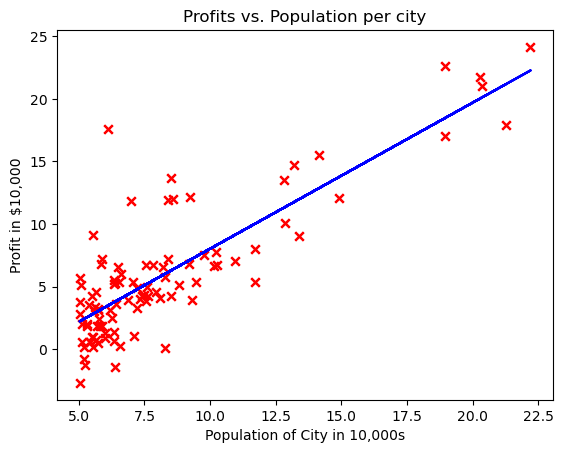

In [ ]:

plt.plot(x_train, predicted, c = "b")
plt.scatter(x_train, y_train, marker='x', c='r')
plt.title("Profits vs. Population per city")
plt.ylabel('Profit in $10,000')
plt.xlabel('Population of City in 10,000s')
plt.show()

In [45]:
predict1 = 3.5 * w + b
print('For population = 35,000, we predict a profit of $%.2f' % (predict1*10000))

predict2 = 7.0 * w + b
print('For population = 70,000, we predict a profit of $%.2f' % (predict2*10000))

For population = 35,000, we predict a profit of $4519.77
For population = 70,000, we predict a profit of $45342.45
